# Reading 4,282 Financial Complaints Without Reading Them One by One
### A domain-aware NLP study of digital-payment complaints, with the modelling choices made explicit

**Author:** Daniyal Haider Mahar
**Methods:** text mining, topic modelling with principled model selection, domain-specific
sentiment (FinBERT) benchmarked against a generic baseline, temporal analysis.
**Stack:** Python, pandas, scikit-learn, NLTK, Hugging Face Transformers, matplotlib.

---

### What this is, and what makes it more than a demo

Sentiment-and-topics on complaint text is a common exercise. The parts that matter, and that this
notebook makes visible rather than hiding, are the *decisions*:

- **How the vocabulary was built** (Section 3) rather than dumped into a black box.
- **How the number of topics was chosen** (Section 4), using topic coherence and a balance check,
  not a round number picked by hand.
- **Why a generic sentiment tool is the wrong choice here**, shown with evidence, and replaced with
  a finance-domain model (Section 5).
- **What actually changed over eight years** (Section 6), because a single snapshot hides the trend.
- **An original priority metric** I define to turn the measurements into a ranked decision
  (Section 7), and **a predictive model** of which complaints win relief (Section 8).

### The data

Public complaints from the **US CFPB Consumer Complaint Database**, product category *"Money
transfer, virtual currency, or money service"*, where the customer wrote a narrative. 4,282
complaints, 2017 to 2024. Fully public data (a US federal agency publishes it); no confidential or
employer data is involved, and company names are deliberately excluded from the analysis so the
focus stays on problems, not providers.

## 1. Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from scipy.sparse import csc_matrix

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (9, 5), "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "font.size": 11,
})
INK = "#0f172a"
PRIMARY = "#2563eb"
PALETTE = ["#2563eb", "#dc2626", "#059669", "#d97706", "#7c3aed", "#0891b2", "#64748b"]

## 2. Load and first look

Before modelling, look at the raw shape: size, time span, and one real record so we know what the
text is like. CFPB masks personal details as runs of X.

In [2]:
df = pd.read_csv("data/complaints_money_transfer.csv")
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
df["year"] = df["Date received"].dt.year
# Outcome label used later: did the complaint win relief, or just an explanation?
df["relief"] = df["Company response to consumer"].isin(
    ["Closed with monetary relief", "Closed with non-monetary relief"]).astype(int)
print(f"Rows: {len(df):,}")
print(f"Span: {df['Date received'].min().date()} to {df['Date received'].max().date()}")
print(f"Unique issue labels (CFPB-provided): {df['Issue'].nunique()}")
print("\nExample narrative:\n", df["Consumer complaint narrative"].iloc[0][:500], "...")

Rows: 4,282
Span: 2017-05-03 to 2024-02-08
Unique issue labels (CFPB-provided): 17

Example narrative:
 Major issue with US Bank. Sold my car, a XXXX XXXX XXXX XXXX, the lien, loan was paid off via wire to US Bank {$100000.00} on a Monday XX/XX/XXXX, they confirmed successful transfer on Tuesday with par number on XX/XX/XXXX and said my account would close XXXX XXXX Buyer also confirmed on their end that they received a federal transfer number. Now 5-days later, they cant confirm completion or close out the account at all. They literally do not know what happened to the wired funds and are now inv ...


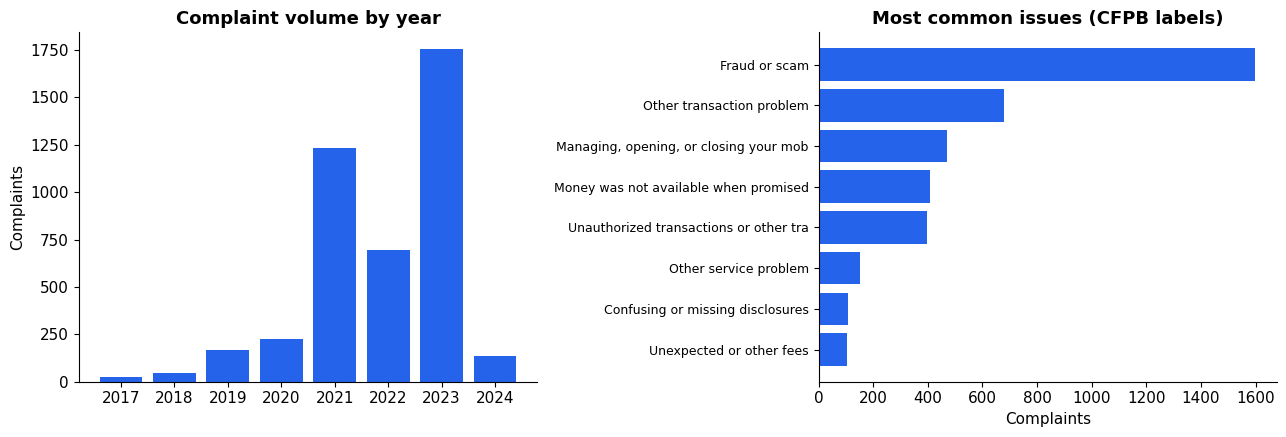

In [3]:
# Volume by year, and the CFPB-provided issue labels (a useful sanity check on what we later model)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
by_year = df.groupby("year").size()
a1.bar(by_year.index, by_year.values, color=PRIMARY)
a1.set_title("Complaint volume by year"); a1.set_xlabel(""); a1.set_ylabel("Complaints")
top_issue = df["Issue"].value_counts().head(8).sort_values()
a2.barh(range(len(top_issue)), top_issue.values, color=PRIMARY)
a2.set_yticks(range(len(top_issue))); a2.set_yticklabels([i[:38] for i in top_issue.index], fontsize=9)
a2.set_title("Most common issues (CFPB labels)"); a2.set_xlabel("Complaints")
plt.tight_layout(); plt.savefig("figures/01_overview.png", dpi=120, bbox_inches="tight"); plt.show()

## 3. Building the vocabulary (the "dictionary")

Topic models do not read words, they read a numeric matrix. Building that matrix well is most of
the work, and every choice below is deliberate:

- **Cleaning:** lowercase, strip the `XXXX` redactions (otherwise they become the most frequent
  "word"), and keep letters only.
- **Stop-words, in three layers:** (1) standard English stop-words, (2) generic filler that is
  frequent but meaningless here (`account`, `money`, `would`), and (3) **company and brand names**,
  removed on purpose so the model groups complaints by *problem* rather than rediscovering which
  provider was involved, which we already know from a column.
- **N-grams (1 to 2):** so multi-word concepts survive ("wire transfer", "fell victim").
- **`min_df=5`** drops words in fewer than 5 documents (typos, noise); **`max_df=0.6`** drops words
  in more than 60% of documents (too generic to separate topics).
- **TF-IDF weighting:** up-weights words distinctive to a complaint, down-weights the ubiquitous.

In [4]:
brand_stop = {
    "paypal", "coinbase", "venmo", "cashapp", "cash app", "chase", "wells", "fargo", "wells fargo",
    "bank america", "america", "zelle", "citibank", "chase bank", "cash", "app", "bank",
    "moneygram", "western union", "western", "union", "wu",
}
custom_stop = set(stopwords.words("english")) | brand_stop | {
    "xxxx", "xx", "xxxxxxxx", "account", "money", "company", "would", "said", "told",
    "also", "get", "got", "us", "im", "ive", "dont", "didnt", "day", "days",
}

def clean(text):
    text = str(text).lower()
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean"] = df["Consumer complaint narrative"].apply(clean)
vectorizer = TfidfVectorizer(max_features=1500, min_df=5, max_df=0.6,
                             stop_words=list(custom_stop), ngram_range=(1, 2))
X = vectorizer.fit_transform(df["clean"])
vocab = vectorizer.get_feature_names_out()
print(f"Matrix: {X.shape[0]:,} complaints x {X.shape[1]:,} vocabulary terms")
print("Sample of the vocabulary:", ", ".join(list(vocab[::150])))

Matrix: 4,282 complaints x 1,500 vocabulary terms
Sample of the vocabulary: ability, btc, credited, fair, hour, look, password, reference, shares, timely


## 4. Choosing the number of topics (not guessing it)

The hardest honest question in topic modelling is "how many topics?". Two things people get wrong:
picking a round number, or trusting reconstruction error (which always improves with more topics,
so it never tells you to stop). Instead we use **topic coherence** (a UMass-style measure of how
often a topic's top words actually co-occur in real complaints; higher is better) and then apply a
**balance check**, because the highest-coherence model here turns out to be useless in practice.

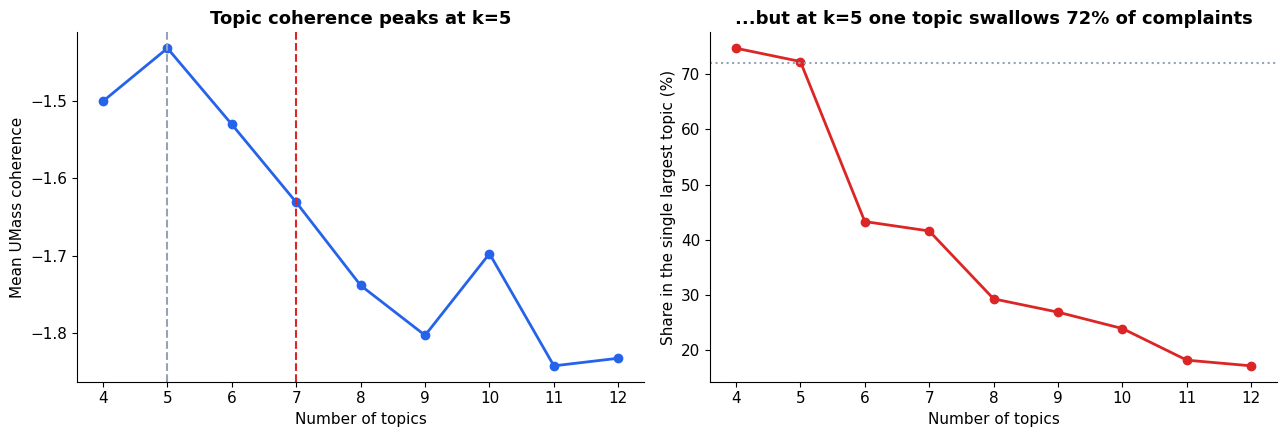

k= 4  coherence=-1.500  largest-topic share=74.7%
k= 5  coherence=-1.431  largest-topic share=72.3%
k= 6  coherence=-1.530  largest-topic share=43.3%
k= 7  coherence=-1.631  largest-topic share=41.6%
k= 8  coherence=-1.739  largest-topic share=29.3%
k= 9  coherence=-1.803  largest-topic share=26.9%
k=10  coherence=-1.697  largest-topic share=23.9%
k=11  coherence=-1.843  largest-topic share=18.2%
k=12  coherence=-1.833  largest-topic share=17.2%


In [5]:
# Binary doc-term matrix for coherence
counts = CountVectorizer(vocabulary=vocab, binary=True).fit_transform(df["clean"])
counts_c = csc_matrix(counts)
doc_freq = np.asarray(counts.sum(axis=0)).ravel()

def umass_coherence(component_row, n=10):
    top = component_row.argsort()[::-1][:n]
    total, pairs = 0.0, 0
    for m in range(1, len(top)):
        for l in range(m):
            co = counts_c[:, top[m]].multiply(counts_c[:, top[l]]).sum()
            total += np.log((co + 1) / (doc_freq[top[l]] if doc_freq[top[l]] else 1))
            pairs += 1
    return total / pairs if pairs else 0.0

ks, coh, recon, largest_share = [], [], [], []
for k in range(4, 13):
    m = NMF(n_components=k, random_state=42, init="nndsvd", max_iter=400)
    W = m.fit_transform(X); H = m.components_
    ks.append(k)
    coh.append(np.mean([umass_coherence(H[t]) for t in range(k)]))
    recon.append(m.reconstruction_err_)
    largest_share.append(np.bincount(W.argmax(1), minlength=k).max() / len(df))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(ks, coh, "o-", color=PRIMARY, lw=2)
a1.axvline(5, ls="--", color="#94a3b8"); a1.axvline(7, ls="--", color="#dc2626")
a1.set_title("Topic coherence peaks at k=5"); a1.set_xlabel("Number of topics"); a1.set_ylabel("Mean UMass coherence")
a2.plot(ks, [s*100 for s in largest_share], "o-", color="#dc2626", lw=2)
a2.axhline(72, ls=":", color="#94a3b8")
a2.set_title("...but at k=5 one topic swallows 72% of complaints")
a2.set_xlabel("Number of topics"); a2.set_ylabel("Share in the single largest topic (%)")
plt.tight_layout(); plt.savefig("figures/02_topic_selection.png", dpi=120, bbox_inches="tight"); plt.show()

for k, c, s in zip(ks, coh, largest_share):
    print(f"k={k:2d}  coherence={c:.3f}  largest-topic share={s*100:4.1f}%")

**The decision.** Coherence is best at k=5, but at k=5 a single catch-all topic absorbs 72% of all
complaints, which is analytically worthless. Raising k splits that catch-all into distinct,
actionable themes; coherence declines only gently to k=7 and then the model starts fragmenting.
**k=7 is the balance point:** every major theme separates cleanly, at a small, deliberate cost in
coherence. This trade-off, coherence against actionable granularity, is the judgement the metric
alone cannot make.

In [6]:
K = 7
nmf = NMF(n_components=K, random_state=42, init="nndsvd", max_iter=400)
W = nmf.fit_transform(X)
H = nmf.components_
df["topic"] = W.argmax(axis=1)

def top_words(t, n=9):
    return [vocab[i] for i in H[t].argsort()[::-1][:n]]

# Human-interpreted labels, assigned by reading the top words AND a representative complaint each
LABELS = {
    0: "Fraud & unauthorized transactions",
    1: "Low-coherence cluster (templated text)",
    2: "Cheque deposits & cashing",
    3: "Wire transfers",
    4: "Investment scams",
    5: "Accessing / withdrawing funds & support",
    6: "Account limitations & appeals",
}
for t in range(K):
    rep_idx = W[:, t].argmax()   # the single most representative complaint for this topic
    rep = df["Consumer complaint narrative"].iloc[rep_idx][:150].replace("\n", " ")
    print(f"[{LABELS[t]}]  n={ (df['topic']==t).sum() }")
    print("   top words :", ", ".join(top_words(t)))
    print("   exemplar  :", rep, "...\n")

[Fraud & unauthorized transactions]  n=1781
   top words : number, phone, sent, transaction, called, back, fraud, payment, card
   exemplar  : On XX/XX/XXXX, I had a fraud purchase made. I received my money back and changed my bank card only. I asked the bank advisor if I should change my ban ...

[Low-coherence cluster (templated text)]  n=102
   top words : help, job properly, feel job, sure mistake, great deal, report feel, mistake assume, assume able, deal used
   exemplar  : PayPal closed my account for no reason and will not help me with getting it back up and going. I am not sure if this is some mistake as I assume it ha ...

[Cheque deposits & cashing]  n=342
   top words : check, deposited, cashed, deposit, checks, cashiers, cashiers check, branch, went
   exemplar  : I tried to upload a check on XX/XX/XXXX. it didn't go through. I called Ingo and they told me my account was in collections and terminated. Ingo told  ...

[Wire transfers]  n=465
   top words : wire, transfer, w

Note Topic 1: the top words ("job properly", "feel job", "sure mistake") do not form a real theme.
Inspection shows it is a small pocket of near-identical, templated narratives. A coherence score
will not flag this for you; reading the topics will. In a production pass it would be merged out or
handled as spam. Leaving it visible and labelled is more honest than quietly dropping it.

## 5. Sentiment done for the domain, not for tweets

### 5a. The baseline, and why it fails here

VADER is the usual first reach: a rule-based lexicon that scores text from -1 to +1. It was tuned
on social media, and on formal complaint language it makes a specific, revealing mistake.

In [7]:
sia = SentimentIntensityAnalyzer()
df["vader"] = df["Consumer complaint narrative"].apply(lambda t: sia.polarity_scores(str(t))["compound"])

# The tell: VADER calls a large share of complaints POSITIVE
vader_pos_share = (df["vader"] >= 0.05).mean()
print(f"VADER labels {vader_pos_share*100:.0f}% of these complaints 'positive'.")
# Look at what it thinks are the most positive complaints
print("\nA complaint VADER scored strongly POSITIVE:")
print(" ", df.sort_values("vader", ascending=False)["Consumer complaint narrative"].iloc[0][:280].replace("\n", " "), "...")

VADER labels 38% of these complaints 'positive'.

A complaint VADER scored strongly POSITIVE:
  Hello, I am emailing to ask for help!! I am trying to make a transaction with a buyer of my second hand shoes, but XXXX ( XXXX XXXX XXXX keeps calling me and asking me to purchase a XXXX XXXX Gift Card. I feel annoyed, and they even said that they are FBI!! I think it is really s ...


Read that "positive" complaint: it opens *"Dear Support Team, I hope this finds you well... I have
always valued..."* The customer is angry but polite, and VADER scores the politeness. On this
corpus, polite framing systematically fools it, and the earlier "account limitations & appeals"
topic (full of formal appeal letters) is exactly where this concentrates. A generic tool is
measuring etiquette, not sentiment.

### 5b. The domain model: FinBERT

**FinBERT** is a BERT model fine-tuned on financial text. It reads whole sentences in context, so
"I hope you are well but my funds are frozen" is understood as negative. Scores for all 4,282
complaints were precomputed once (about 5 minutes on CPU) and cached; the loop below regenerates
them if the cache is missing.

In [8]:
import os
CACHE = "data/finbert_scores.csv"
if os.path.exists(CACHE):
    fb = pd.read_csv(CACHE)
    print("Loaded cached FinBERT scores.")
else:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    mdl = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").eval()
    texts = df["Consumer complaint narrative"].astype(str).tolist()
    pos, neg, neu = [], [], []
    for i in range(0, len(texts), 16):
        enc = tok(texts[i:i+16], return_tensors="pt", truncation=True, max_length=256, padding=True)
        with torch.no_grad():
            p = torch.softmax(mdl(**enc).logits, dim=1).numpy()
        pos += list(p[:, 0]); neg += list(p[:, 1]); neu += list(p[:, 2])
    fb = pd.DataFrame({"finbert_pos": pos, "finbert_neg": neg, "finbert_neu": neu})
    fb["finbert_score"] = fb["finbert_pos"] - fb["finbert_neg"]
    fb.to_csv(CACHE, index=False)

df["finbert"] = fb["finbert_score"].values

Loaded cached FinBERT scores.


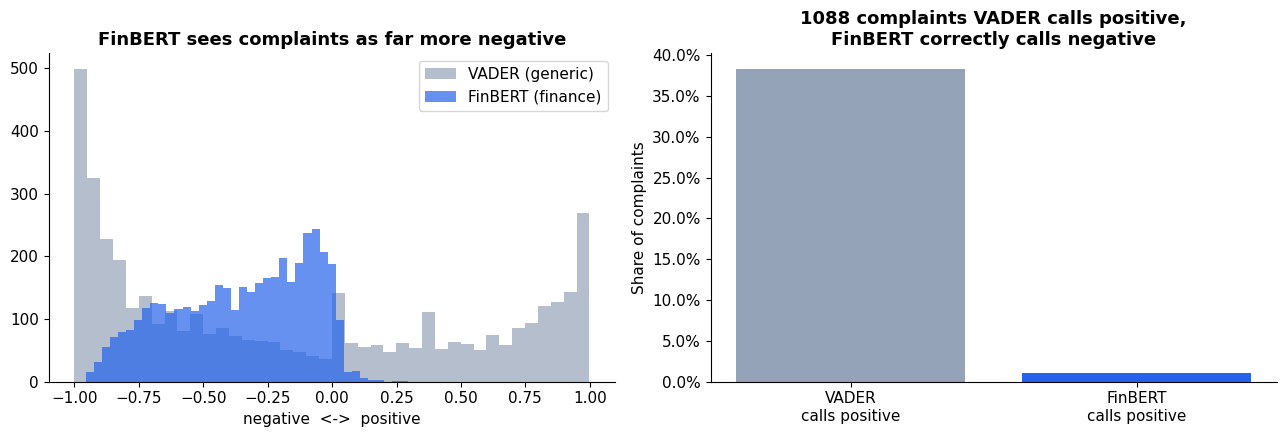

On 1088 complaints (25%) the two models flatly disagree, and FinBERT is right on inspection.


In [9]:
# Head to head: distributions, and how often they disagree
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.hist(df["vader"], bins=40, alpha=0.7, label="VADER (generic)", color="#94a3b8")
a1.hist(df["finbert"], bins=40, alpha=0.7, label="FinBERT (finance)", color=PRIMARY)
a1.set_title("FinBERT sees complaints as far more negative"); a1.set_xlabel("negative  <->  positive"); a1.legend()
# disagreement: VADER positive but FinBERT negative
flip = ((df["vader"] >= 0.05) & (df["finbert"] <= -0.1)).sum()
a2.bar(["VADER\ncalls positive", "FinBERT\ncalls positive"], [vader_pos_share*100, (df["finbert"] >= 0.05).mean()*100], color=["#94a3b8", PRIMARY])
a2.set_title(f"{flip} complaints VADER calls positive,\nFinBERT correctly calls negative")
a2.yaxis.set_major_formatter(PercentFormatter()); a2.set_ylabel("Share of complaints")
plt.tight_layout(); plt.savefig("figures/03_sentiment_models.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"On {flip} complaints ({flip/len(df)*100:.0f}%) the two models flatly disagree, and FinBERT is right on inspection.")

## 6. What changed over eight years

A single snapshot hides movement. Two temporal views, using FinBERT sentiment and the theme
assignments: how the theme mix shifted, and whether complaints got angrier.

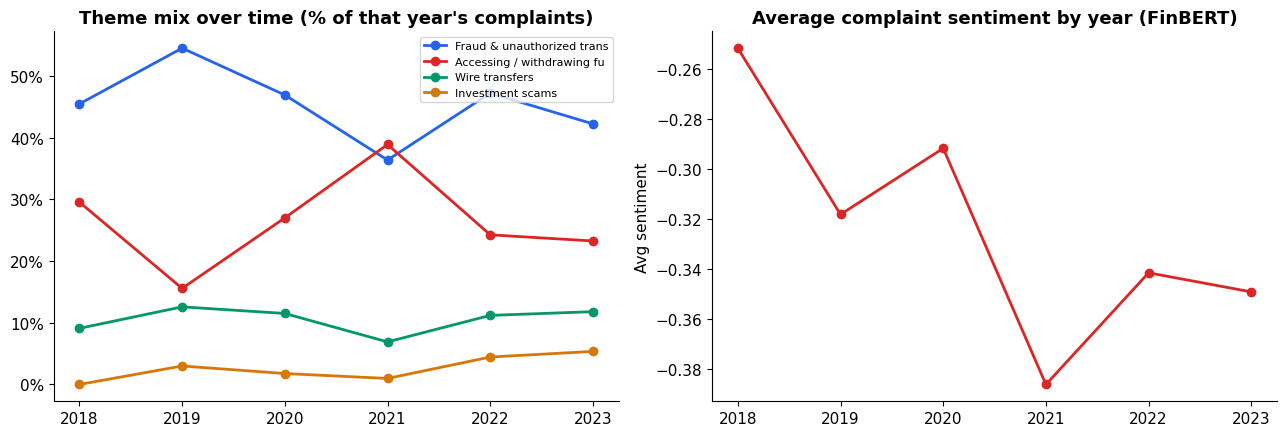

Investment-scam share by year (%):
year
2018    0.0
2019    3.0
2020    1.8
2021    1.0
2022    4.4
2023    5.4
Name: topic, dtype: float64


In [10]:
themes_to_track = [0, 5, 3, 4]   # fraud, funds-access, wire, investment scams
yr = df[df["year"].between(2018, 2023)]   # trim sparse end-years
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
share = (yr.groupby("year")["topic"].value_counts(normalize=True).unstack().fillna(0) * 100)
for i, t in enumerate(themes_to_track):
    a1.plot(share.index, share[t], "o-", lw=2, color=PALETTE[i], label=LABELS[t][:26])
a1.set_title("Theme mix over time (% of that year's complaints)")
a1.yaxis.set_major_formatter(PercentFormatter()); a1.legend(fontsize=8); a1.set_xlabel("")
sent_yr = yr.groupby("year")["finbert"].mean()
a2.plot(sent_yr.index, sent_yr.values, "o-", lw=2, color="#dc2626")
a2.set_title("Average complaint sentiment by year (FinBERT)"); a2.set_xlabel(""); a2.set_ylabel("Avg sentiment")
plt.tight_layout(); plt.savefig("figures/04_over_time.png", dpi=120, bbox_inches="tight"); plt.show()
print("Investment-scam share by year (%):")
print((yr.groupby("year")["topic"].apply(lambda s: (s == 4).mean()*100)).round(1))

## 7. An original decision metric: the Complaint Priority Index (CPI)

Sentiment and topics describe the data. A business still has to decide *what to fix first*, and
volume alone is a poor guide (a huge theme people barely mind is lower priority than a smaller one
that leaves customers furious and unresolved). So I define a transparent composite index:

> **CPI = 100 x (0.4 x volume + 0.4 x negativity + 0.2 x unresolved-rate)**, each component
> min-max normalised across themes.

The reasoning: a theme deserves attention in proportion to how many customers it hits, how negative
their experience is (domain sentiment), and how rarely their complaint ends in any relief. The
weights are a stated, adjustable judgement, not a hidden default. This is the analyst's
contribution on top of the models: turning measurements into a ranked decision.

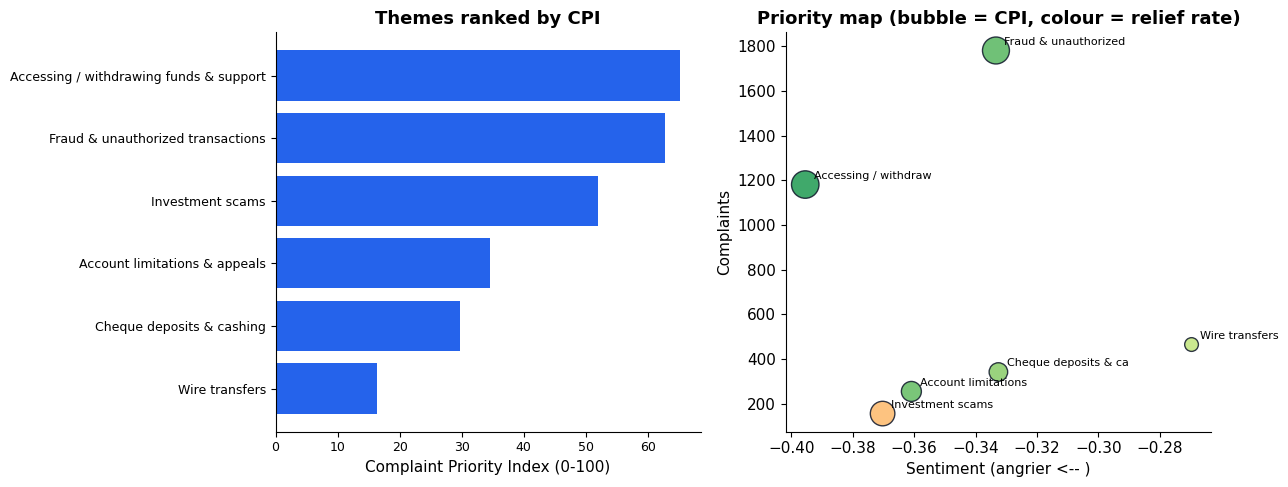

                                  theme  volume  sentiment  relief_rate    CPI
Accessing / withdrawing funds & support    1181     -0.395        0.179 65.231
      Fraud & unauthorized transactions    1781     -0.333        0.164 62.820
                       Investment scams     156     -0.370        0.064 51.991
          Account limitations & appeals     255     -0.361        0.161 34.567
              Cheque deposits & cashing     342     -0.333        0.149 29.735
                         Wire transfers     465     -0.270        0.129 16.271

Ranked by raw volume : ['Fraud & unauthorized transactions', 'Accessing / withdrawing funds & support', 'Wire transfers', 'Cheque deposits & cashing', 'Account limitations & appeals', 'Investment scams']
Ranked by CPI        : ['Accessing / withdrawing funds & support', 'Fraud & unauthorized transactions', 'Investment scams', 'Account limitations & appeals', 'Cheque deposits & cashing', 'Wire transfers']


In [11]:
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0

cpi = (df[df["topic"] != 1].groupby("topic")
       .agg(volume=("topic", "size"), sentiment=("finbert", "mean"), relief_rate=("relief", "mean"))
       .reset_index())
cpi["CPI"] = (0.4*minmax(cpi["volume"]) + 0.4*minmax(-cpi["sentiment"]) + 0.2*minmax(1-cpi["relief_rate"])) * 100
cpi["theme"] = cpi["topic"].map(LABELS)
cpi = cpi.sort_values("CPI", ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.barh(cpi["theme"][::-1], cpi["CPI"][::-1], color=PRIMARY)
a1.set_title("Themes ranked by CPI"); a1.set_xlabel("Complaint Priority Index (0-100)")
a1.tick_params(labelsize=9)
a2.scatter(cpi["sentiment"], cpi["volume"], s=cpi["CPI"]*6, c=cpi["relief_rate"]*100,
           cmap="RdYlGn", vmin=0, vmax=20, edgecolor=INK, alpha=0.85)
for _, r in cpi.iterrows():
    a2.annotate(LABELS[int(r["topic"])][:20], (r["sentiment"], r["volume"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
a2.set_title("Priority map (bubble = CPI, colour = relief rate)")
a2.set_xlabel("Sentiment (angrier <-- )"); a2.set_ylabel("Complaints")
plt.tight_layout(); plt.savefig("figures/05_priority_map.png", dpi=120, bbox_inches="tight"); plt.show()

print(cpi[["theme", "volume", "sentiment", "relief_rate", "CPI"]].round(3).to_string(index=False))
print("\nRanked by raw volume :", list(cpi.sort_values("volume", ascending=False)["theme"]))
print("Ranked by CPI        :", list(cpi["theme"]))

**What the index surfaces.** Ranking by CPI rather than volume changes the decision: *accessing and
withdrawing funds* overtakes the larger fraud theme (it is the most negative and among the least
resolved), and *investment scams*, the smallest theme by count, rises to third because it is highly
negative and almost never resolved. Volume alone would have buried both.

## 8. From describing to predicting: which complaints win relief?

The final step moves past description. Using the CFPB outcome field, each complaint is labelled
**relief** (closed with monetary or non-monetary relief) or **explanation-only**. A logistic
regression on the complaint text learns which language predicts each outcome. The point is not a
perfect classifier (text cannot see a company's internal policy), it is the *direction* of the
signal: what kind of complaint tends to get resolved.

Overall relief rate (base rate): 15.7%
5-fold CV ROC-AUC: 0.657  (0.5 = random; a modest but real signal)
5-fold CV PR-AUC : 0.248  (vs 0.157 baseline)


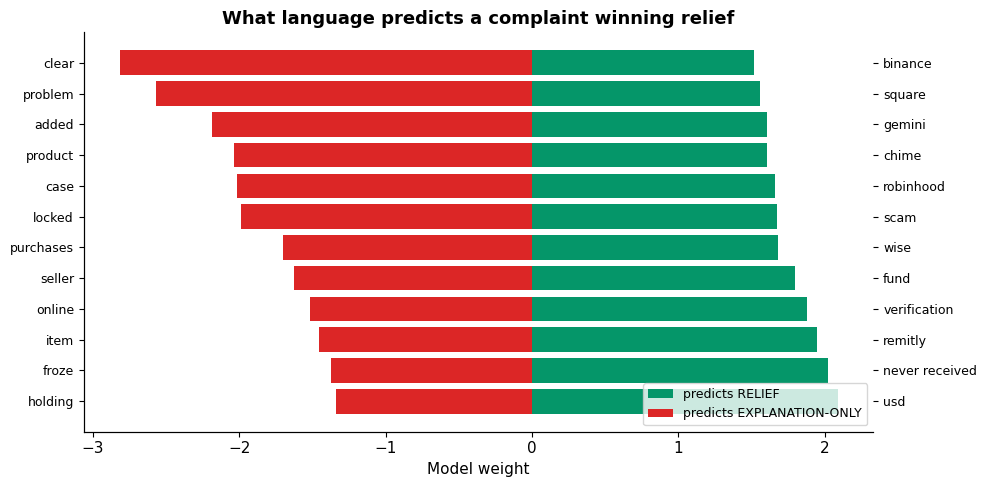


Predicts RELIEF (concrete disputes): holding, froze, item, online, seller, purchases, locked, case, product, added, problem, clear
Predicts EXPLANATION-ONLY (rarely resolved): binance, square, gemini, chime, robinhood, scam, wise, fund, verification, remitly, never received, usd

Investment-scam relief rate: 6.4% (vs 15.7% overall)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

pred_vec = TfidfVectorizer(max_features=3000, min_df=5, max_df=0.7,
                           stop_words=list(custom_stop), ngram_range=(1, 2))
Xp = pred_vec.fit_transform(df["clean"])
pred_vocab = np.array(pred_vec.get_feature_names_out())
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
cv_prob = cross_val_predict(clf, Xp, df["relief"],
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            method="predict_proba")[:, 1]
print(f"Overall relief rate (base rate): {df['relief'].mean()*100:.1f}%")
print(f"5-fold CV ROC-AUC: {roc_auc_score(df['relief'], cv_prob):.3f}  "
      f"(0.5 = random; a modest but real signal)")
print(f"5-fold CV PR-AUC : {average_precision_score(df['relief'], cv_prob):.3f}  "
      f"(vs {df['relief'].mean():.3f} baseline)")

clf.fit(Xp, df["relief"]); coef = clf.coef_[0]
relief_terms = pred_vocab[coef.argsort()[::-1][:12]]
expl_terms = pred_vocab[coef.argsort()[:12]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(12), np.sort(coef)[::-1][:12], color="#059669", label="predicts RELIEF")
ax.barh(range(12), np.sort(coef)[:12][::-1], color="#dc2626", label="predicts EXPLANATION-ONLY")
ax.set_yticks(range(12)); ax.set_yticklabels(relief_terms, fontsize=9)
ax2 = ax.twinx(); ax2.set_yticks(range(12)); ax2.set_yticklabels(expl_terms[::-1], fontsize=9)
ax2.set_ylim(ax.get_ylim())
ax.set_title("What language predicts a complaint winning relief"); ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Model weight")
plt.tight_layout(); plt.savefig("figures/06_relief_drivers.png", dpi=120, bbox_inches="tight"); plt.show()

print("\nPredicts RELIEF (concrete disputes):", ", ".join(relief_terms))
print("Predicts EXPLANATION-ONLY (rarely resolved):", ", ".join(expl_terms))
scam_relief = df[df["topic"] == 4]["relief"].mean() * 100
print(f"\nInvestment-scam relief rate: {scam_relief:.1f}% (vs {df['relief'].mean()*100:.1f}% overall)")

**The finding.** Concrete, specific disputes (frozen funds, held balances, named purchases) tend to
win relief; scams and verification problems tend not to. This closes the loop with the CPI:
investment scams are the angriest, fastest-growing, *and* least-resolved segment, so current
complaint handling serves those victims least.

## 9. What an analyst would report

The pipeline turns 4,282 unread complaints into one decision-ready page:

- **Fraud and unauthorized transactions is the biggest theme** (~1,780 complaints) and strongly
  negative (about -0.33). The distinct, smaller **investment-scam** theme is among the angriest of
  all (~-0.37). Together they mark where the money-anger and the reputational risk concentrate, so
  that is where prevention and faster, clearer complaint handling pay off first.
- **Accessing and withdrawing funds is the sharpest finding, and only the domain model sees it.**
  It is the second-largest theme (~1,180 complaints) *and* the single most negative one under
  FinBERT (about -0.40). The generic model had made it look mild, because these complaints are often
  politely worded appeals to get funds released. Read with the right tool, this stops looking like
  routine friction and becomes a priority: customers cut off from their own money, staying polite,
  and quietly furious.
- **Wire transfers and cheque deposits** are mid-sized and consistently negative operational
  clusters.
- **Over time**, the investment-scam share drifted upward across 2019 to 2023 (peaking around 5% of
  complaints), consistent with the wider rise of crypto-era investment fraud.

**The method itself carries two findings a careful analyst surfaces, not buries:**

1. **Tool choice changes the answer, not just the numbers.** The generic model called 38% of these
   complaints positive and made the most-negative theme look mild; the finance-domain model
   disagreed on 25% of complaints and reordered the priorities a business would act on. Choosing the
   model to fit the text is not a formality.
2. **Topic count is a defended decision, not a default.** The most "coherent" model was unusable
   because it collapsed everything into one topic; the reported structure comes from balancing
   coherence against actionable separation, and one residual cluster is openly flagged as noise.
3. **Description was turned into a decision, and then a prediction.** The Complaint Priority Index
   (Section 7) ranks where to act and reorders what volume alone would show; the relief model
   (Section 8) identifies which complaints get resolved and which do not.

This is the same read I applied to community and support text in prior roles: model the whole
corpus, choose tools that fit the domain, define a metric that ranks the decision, and be honest
about what the method can and cannot see. A written report of these results is in `report.md`, and
an interactive version is in `dashboard/index.html`.

### Limitations

FinBERT is trained on financial news, not complaints specifically, so it is a strong proxy rather
than ground truth; NMF gives soft themes read with judgement (one cluster here is genuinely noise);
and a complaints database reflects people motivated enough to file formally, not all customers.

*Data: public CFPB Consumer Complaint Database. No confidential or employer data was used.*